# Cellular Automata

We study elementary 1D rules with progressive visual checkpoints.


## Rule and initialization


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

rule = 110
bits = np.array(list(np.binary_repr(rule, width=8)), dtype=int)
n = 260
T = 180
state = np.zeros(n, dtype=int)
state[n//2] = 1
S = [state.copy()]


## Time stepping


In [2]:
for _ in range(T):
    left = np.roll(state, 1)
    right = np.roll(state, -1)
    idx = 4*left + 2*state + right
    state = bits[7 - idx]
    S.append(state.copy())
S = np.array(S)


## Result visualization


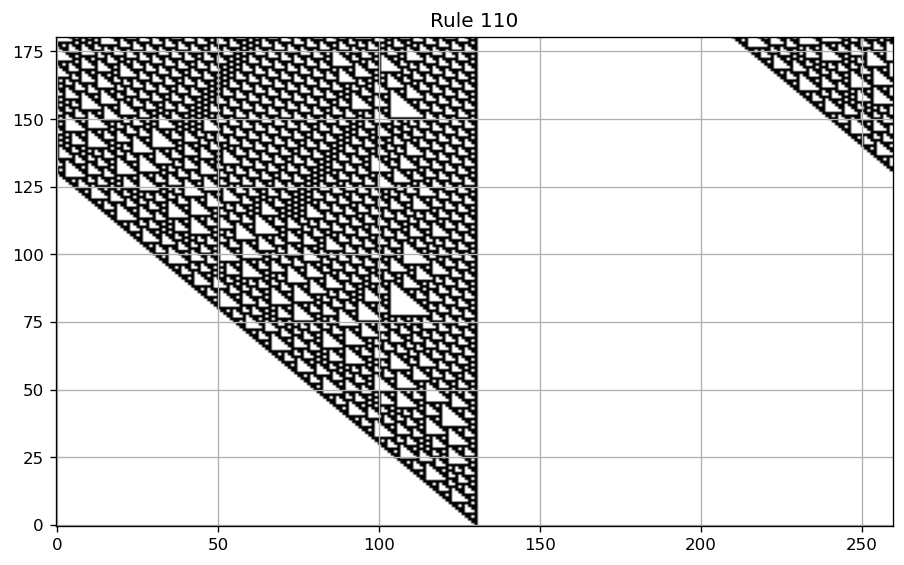

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.3))
ax.imshow(S, cmap='binary', origin='lower', aspect='auto')
ax.set_title(f'Rule {rule}')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
